In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import pyNeuroDAP as ndap

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import pyNeuroDAP as ndap

Each neuron: laser_mod_index <--> left_right_tone_index, left_right_lick_index, reward_index

- tone: 25 ms
- reward is delivered as soon as the first selection lick is detected
- ENL: 1500 + np.ranodom(0,500)

## 1. Load the data from folder

In [3]:
# import tkinter as tk
# from tkinter import filedialog
# # Hide the main tkinter window
# root = tk.Tk()
# root.withdraw()

# # Open a dialog to select the session folder
# base_folder = filedialog.askdirectory(title="Select session folder", initialdir=r"/Users/shunli/Downloads/sabalab/forPaolo")
# # Extract the session_id from the selected folder name
# session_id = os.path.basename(base_folder)
# print(f"Selected session_id: {session_id}")
# print(f"Base folder: {base_folder}")

In [4]:
# Hard loading

base_folder = rf"/Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"

# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250323_5mW_500ms_500delay_032325001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250328_Licking_032825001"

# Extract the session_id from the last part of the path
session_id = os.path.basename(base_folder)
print(f"Selected session_id: {session_id}")

Selected session_id: Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001


In [5]:
# Load data from hdf5 file
data_path = base_folder + "/results-250820/data.h5"
data = ndap.load_session_data(data_path)

trial_table = ndap.load_dataframe(data_path, key='trial_table')
event_times = data['event_times']
metadata = data['metadata']

# Load aligned spikes
spikes_path = base_folder + "/results-250820/aligned_spikes.h5"
aligned_spikes = ndap.load_aligned_spikes(spikes_path)

aligned_trial_start = aligned_spikes['trial_start']
aligned_choice_lick = aligned_spikes['choice_lick']
aligned_second_lick = aligned_spikes['second_lick']
aligned_last_lick = aligned_spikes['last_lick']

DataFrame loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Variables loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Variables loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Session data loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
DataFrame loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Aligned spikes loaded from /Users/shunli/Projects/pyNeuroDAP/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/aligned_spikes.h5 (lazy=True)


In [6]:
type(aligned_trial_start['reward_left_laser']['rate'])              # numpy.ndarray or h5py.Dataset?
# getattr(aligned_trial_start, 'nbytes', None)

h5py._hl.dataset.Dataset

### 3.2. Get modulation index

- Tone
- Choice lick (left vs right encoding)
- reward
- laser

In [7]:
time_range = (-1,2)
bin_size = metadata['bin_size']

nbins = int(np.round((time_range[1] - time_range[0]) / (bin_size/1000)))
xaxis = np.linspace(time_range[0],time_range[1],nbins)

In [8]:
mod_index_type = 'norm'

# ----------------------------- Tone -----------------------------
response_window = (0, 50)   # start at 10 ms, end at 200 ms

# combined event and control data
tone_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
tone_rates = ndap.combine_rates([aligned_trial_start[k]['rate'] for k in tone_keys], axis=1)

control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
ctrl_rates = ndap.combine_rates([aligned_trial_start[k]['rate'] for k in control_keys], axis=1)

# get tone mod index
tone_rates = ndap.get_window(tone_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=(-75,-25), time_range=time_range, bin_size_ms=bin_size)
tone_mod_index = ndap.get_mod_index(tone_rates, ctrl_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(tone_mod_index)[-5:][::-1]
idx_supp    = np.argsort(tone_mod_index)[:5]
print("Top 5 excited neurons by tone:", idx_excited, tone_mod_index[idx_excited])
print("Top 5 suppressed neurons by tone:", idx_supp, tone_mod_index[idx_supp])


# ----------------------------- Choice (left vs right encoding) -----------------------------
response_window = (0, 75)   # start at 10 ms, end at 200 ms

# combined event and control data
left_keys = ['reward_left_control', 'nonreward_left_control']
left_rates = ndap.combine_rates([aligned_choice_lick[k]['rate'] for k in left_keys], axis=1)

right_keys = ['reward_right_control', 'nonreward_right_control']
right_rates = ndap.combine_rates([aligned_choice_lick[k]['rate'] for k in right_keys], axis=1)

# get mod index
left_rates = ndap.get_window(left_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
right_rates = ndap.get_window(right_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
choice_mod_index = ndap.get_mod_index(left_rates, right_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(choice_mod_index)[-5:][::-1]
idx_supp    = np.argsort(choice_mod_index)[:5]
print("Top 5 excited neurons by choice:", idx_excited, choice_mod_index[idx_excited])
print("Top 5 suppressed neurons by choice", idx_supp, choice_mod_index[idx_supp])


# ----------------------------- Motor -----------------------------
response_window = (0, 100)   # start at 10 ms, end at 200 ms
control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
ctrl_rates = ndap.combine_rates([aligned_last_lick[k]['rate'] for k in control_keys], axis=1)

# get mod index
lick_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=(150,250), time_range=time_range, bin_size_ms=bin_size)
motor_mod_index = ndap.get_mod_index(lick_rates, ctrl_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(motor_mod_index)[-5:][::-1]
idx_supp    = np.argsort(motor_mod_index)[:5]
print("Top 5 excited neurons by motor:", idx_excited, motor_mod_index[idx_excited])
print("Top 5 suppressed neurons by motor:", idx_supp, motor_mod_index[idx_supp])


# ----------------------------- Reward -----------------------------
response_window = (0, 200)   # start at 10 ms, end at 200 ms

# combined event and control data
reward_keys = ['reward_left_control', 'reward_right_control']
reward_rates = ndap.combine_rates([aligned_second_lick[k]['rate'] for k in reward_keys], axis=1)

nonreward_keys = ['nonreward_left_control', 'nonreward_right_control']
nonreward_rates = ndap.combine_rates([aligned_second_lick[k]['rate'] for k in nonreward_keys], axis=1)

# get mod index
reward_rates = ndap.get_window(reward_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
nonreward_rates = ndap.get_window(nonreward_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
reward_mod_index = ndap.get_mod_index(reward_rates, nonreward_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(reward_mod_index)[-5:][::-1]
idx_supp    = np.argsort(reward_mod_index)[:5]
print("Top 5 excited neurons by reward:", idx_excited, reward_mod_index[idx_excited])
print("Top 5 suppressed neurons by reward:", idx_supp, reward_mod_index[idx_supp])


# ----------------------------- Laser -----------------------------
laser_onset = 1.0                   # in sec
response_window = (10, 200)   # start at 10 ms, end at 200 ms

# combined event and control data
laser_keys = ['reward_left_laser', 'nonreward_left_laser', 'reward_right_laser', 'nonreward_right_laser']
laser_rates = ndap.combine_rates([aligned_trial_start[k]['rate'] for k in laser_keys], axis=1)

control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
control_rates = ndap.combine_rates([aligned_trial_start[k]['rate'] for k in control_keys], axis=1)

# get laser mod index
laser_rates = ndap.get_window(laser_rates, onset_time=laser_onset, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
control_rates = ndap.get_window(control_rates, onset_time=laser_onset, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
laser_mod_index = ndap.get_mod_index(laser_rates, control_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(laser_mod_index)[-5:][::-1]
idx_supp    = np.argsort(laser_mod_index)[:5]
print("Top 5 excited neurons by laser:", idx_excited, laser_mod_index[idx_excited])
print("Top 5 suppressed neurons by laser:", idx_supp, laser_mod_index[idx_supp])

Top 5 excited neurons by tone: [60 50 68 17  2] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by tone: [23 22 37 79 97] [-1.         -1.         -0.74468085 -0.62068966 -0.6       ]
Top 5 excited neurons by choice: [  5  43  78 123  47] [1.         1.         1.         0.49560117 0.47806999]
Top 5 suppressed neurons by choice [106 110  98  10  31] [-1. -1. -1. -1. -1.]
Top 5 excited neurons by motor: [ 80  78 104 116  31] [1.         1.         1.         0.53781513 0.5       ]
Top 5 suppressed neurons by motor: [123  26  96 107  68] [-1.         -1.         -1.         -1.         -0.95918367]
Top 5 excited neurons by reward: [43 51 56  9 27] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by reward: [17 59 36  7 31] [-1.         -1.         -1.         -1.         -0.80043384]
Top 5 excited neurons by laser: [56 29 60 63 72] [1.         0.64699673 0.632469   0.61720259 0.59070935]
Top 5 suppressed neurons by laser: [ 41 110  43   4  17] [-1. -1. -1. -1. -1.]


### 3.3. Plot modulation index

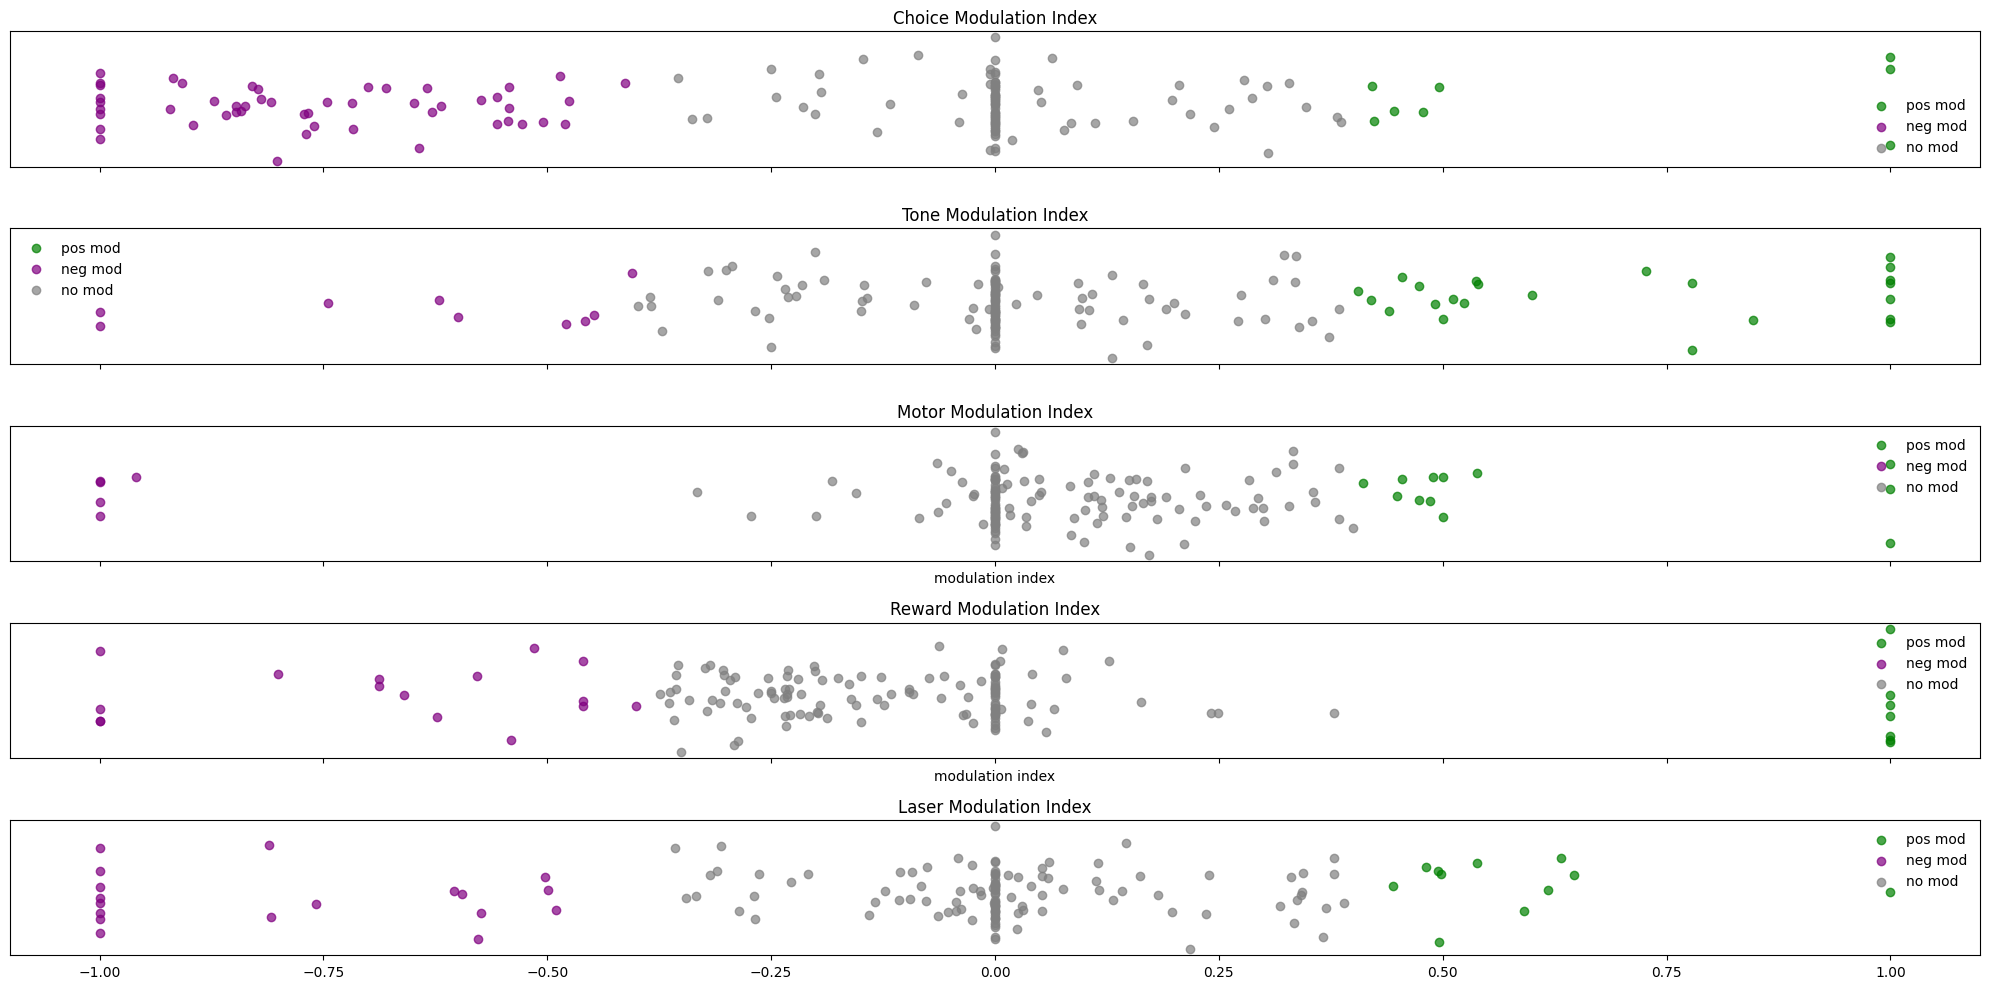

In [9]:
# Plot and group all modulation indices in a 2x2 grid of subplots
mod_indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index),
    ("Laser Modulation Index", laser_mod_index)
]

fig, axes = plt.subplots(len(mod_indices), 1, figsize=(20, 10), sharex=True)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

# Use the same y_jitter for all plots, based on the number of units (assume all mod indices have same length)
y_jitter = np.random.normal(loc=0, scale=0.1, size=laser_mod_index.size)

pos_mod_color = 'green'
neg_mod_color = 'purple'
no_mod_color = 'gray'
th = 0.4

for ax, (title, mod_index) in zip(axes_flat, mod_indices):
    pos_mask = mod_index > th
    neg_mask = mod_index < -th
    no_mask  = (~pos_mask & ~neg_mask)
    ax.scatter(mod_index[pos_mask], y_jitter[pos_mask],
               color=pos_mod_color, alpha=0.7, label='pos mod')
    ax.scatter(mod_index[neg_mask], y_jitter[neg_mask],
               color=neg_mod_color, alpha=0.7, label='neg mod')
    ax.scatter(mod_index[no_mask],  y_jitter[no_mask],
               color=no_mod_color,  alpha=0.7, label='no mod')
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_title(title)
    ax.legend(frameon=False)

# Set xlabel only for bottom row
for i, ax in enumerate(axes_flat):
    if i // 2 == 1:  # bottom row
        ax.set_xlabel('modulation index')

plt.tight_layout()

/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_21382/642381697.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


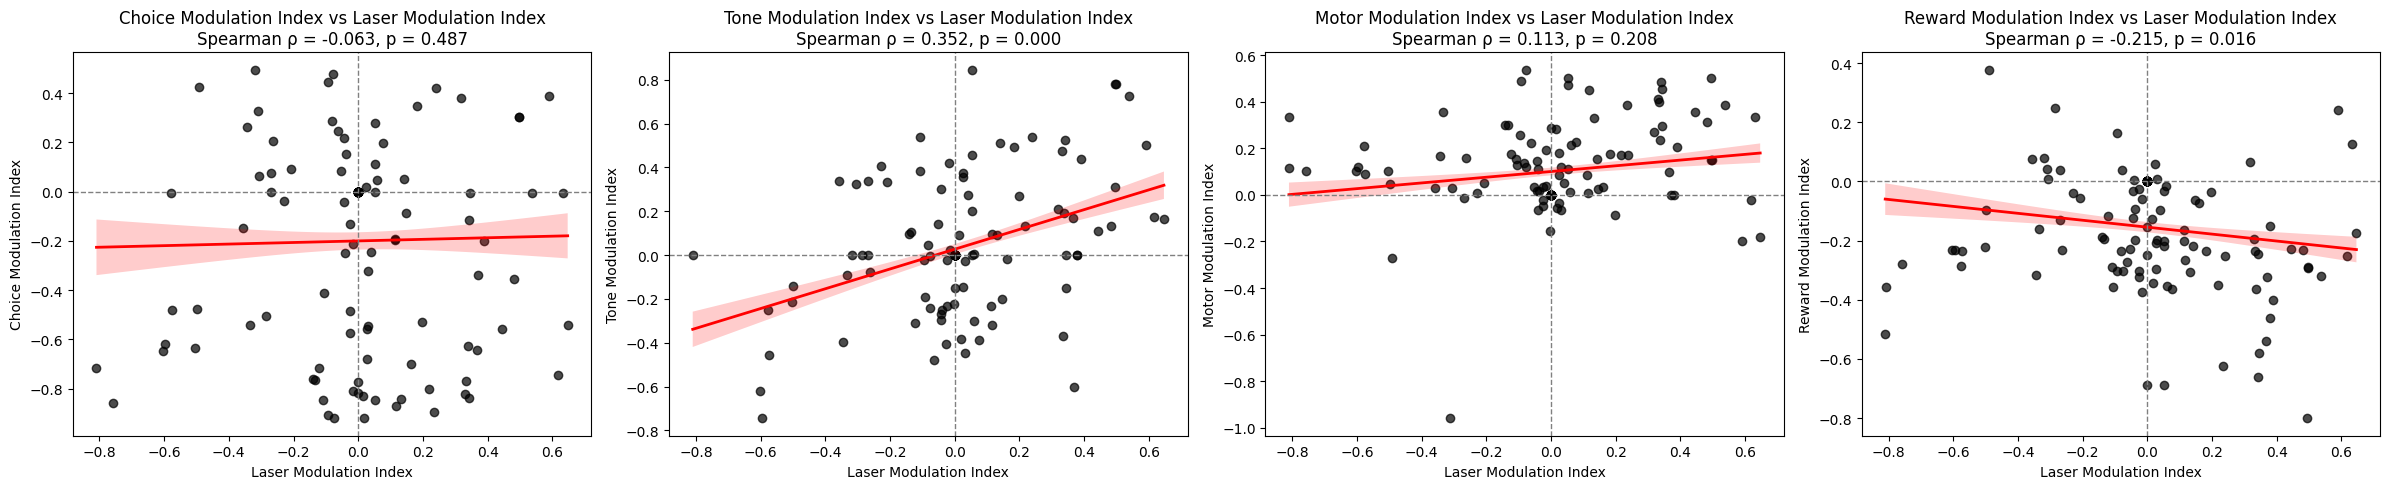

In [10]:
# Three scatter plots: laser_mod_index (x) vs other indices (y), 1 row x 3 columns, with best fit line and Spearman correlation
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index)
]

for ax, (title, y_index) in zip(axes, indices):
    # Remove indices of 1 and -1
    tol = 1e-8
    mask = ~(
        np.isclose(np.abs(laser_mod_index), 1.0, atol=tol) |
        np.isclose(np.abs(y_index), 1.0, atol=tol)
    )
    laser_mod_index_clean = laser_mod_index[mask]
    y_index_clean = y_index[mask]

    # Scatter plot
    ax.scatter(laser_mod_index_clean, y_index_clean, color='black', alpha=0.7)
    # Best fit line (linear regression)
    m, b = np.polyfit(laser_mod_index_clean, y_index_clean, 1)
    x_fit = np.linspace(np.min(laser_mod_index_clean), np.max(laser_mod_index_clean), 100)
    y_fit = m * x_fit + b

    # Calculate SEM of the fit line
    # For each x_fit, compute predicted y, then SEM of residuals
    y_pred = m * laser_mod_index_clean + b
    residuals = y_index_clean - y_pred
    # Standard error of the regression (residuals)
    n = len(laser_mod_index_clean)
    if n > 2:
        s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    else:
        s_err = np.nan

    # For each x_fit, calculate SEM of the fit line
    x_mean = np.mean(laser_mod_index_clean)
    Sxx = np.sum((laser_mod_index_clean - x_mean) ** 2)
    if Sxx > 0 and n > 2:
        sem_fit = s_err * np.sqrt(1/n + (x_fit - x_mean)**2 / Sxx)
    else:
        sem_fit = np.full_like(x_fit, np.nan)

    ax.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2)
    ax.fill_between(x_fit, y_fit - sem_fit, y_fit + sem_fit, color='red', alpha=0.2, edgecolor='None')

    # Spearman correlation
    rho, pval = spearmanr(laser_mod_index_clean, y_index_clean)
    ax.set_xlabel('Laser Modulation Index')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Laser Modulation Index\nSpearman ρ = {rho:.3f}, p = {pval:.3f}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Laser modulation index: -0.5738784068772274
Tone modulation index: -0.4576271186439274
Choice modulation index: -0.48069980560953457
Reward modulation index: -0.23470494597602


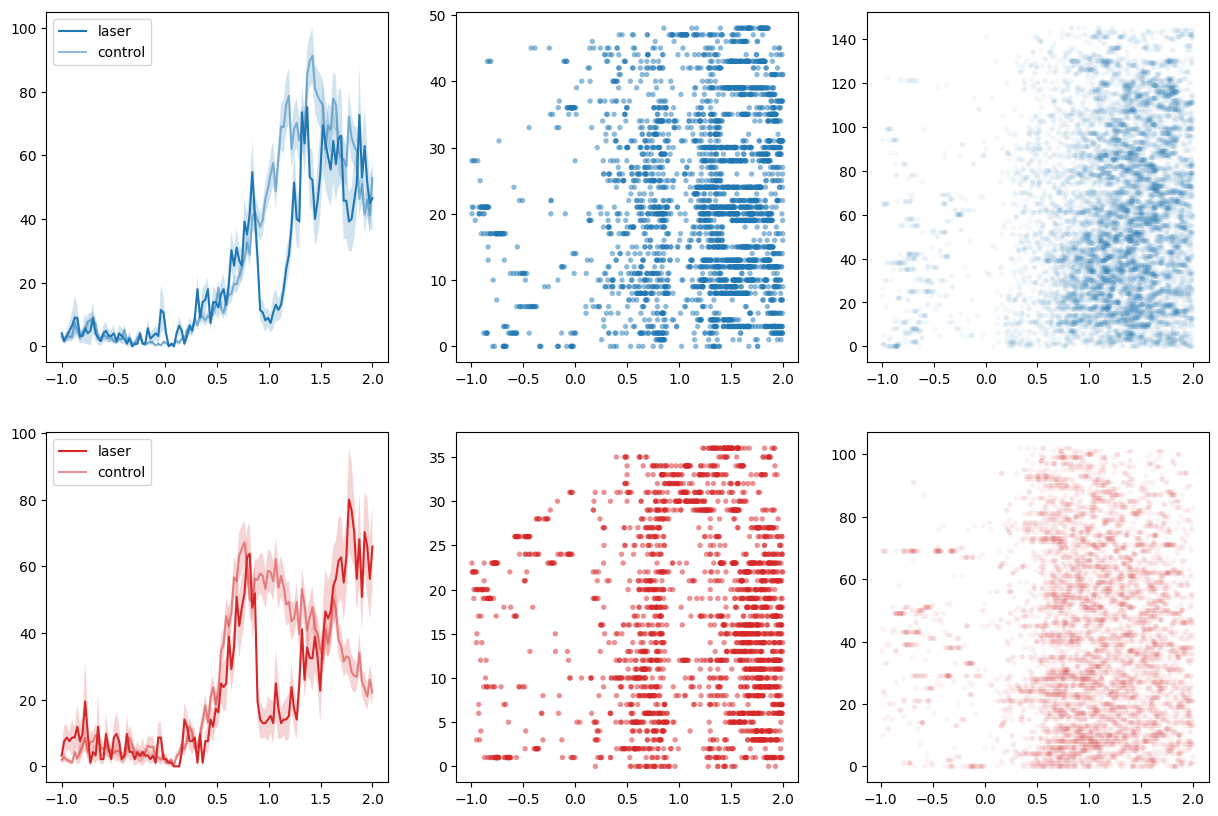

In [11]:
# Plot firing rate per neuron
# 73: high firing, 23, 67, 37: modulated
fig, ax = plt.subplots(2,3,figsize=(15,10))
unit_id = 67

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.5
alpha_laser  = 1.0

aligned = aligned_trial_start

# Row 0: left trials
ndap.plot_sem(aligned['reward_left_laser']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_laser, plot_individual=False, ax=ax[0,0], label='laser')
ndap.plot_sem(aligned['reward_left_control']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[0,0], label='control')
ax[0,0].legend()
ndap.plot_raster(aligned['reward_left_laser']['times'][unit_id], x=xaxis, color=left_color, alpha=0.5*alpha_laser, ax=ax[0,1])
ndap.plot_raster(aligned['reward_left_control']['times'][unit_id], x=xaxis, color=left_color, alpha=0.1*alpha_ctrl, ax=ax[0,2])

# Row 1: right trials
ndap.plot_sem(aligned['reward_right_laser']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_laser, plot_individual=False, ax=ax[1,0], label='laser')
ndap.plot_sem(aligned['reward_right_control']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[1,0], label='control')
ax[1,0].legend()
ndap.plot_raster(aligned['reward_right_laser']['times'][unit_id], x=xaxis, color=right_color, alpha=0.5*alpha_laser, ax=ax[1,1])
ndap.plot_raster(aligned['reward_right_control']['times'][unit_id], x=xaxis, color=right_color, alpha=0.1*alpha_ctrl, ax=ax[1,2])


print('Laser modulation index: ' + str(laser_mod_index[unit_id]))
print('Tone modulation index: ' + str(tone_mod_index[unit_id]))
print('Choice modulation index: ' + str(choice_mod_index[unit_id]))
print('Reward modulation index: ' + str(reward_mod_index[unit_id]))

## 4. Plot trajectory aligned to events

In [12]:
# combine left and right data
criteria = None
aligned = aligned_last_lick

left_control_keys = ['reward_left_control', 'nonreward_left_control']
left_laser_keys = ['reward_left_laser', 'nonreward_left_laser']
right_control_keys = ['reward_right_control', 'nonreward_right_control']
right_laser_keys = ['reward_right_laser', 'nonreward_right_laser']

left_list_control = [aligned[k]['rate'] for k in left_control_keys]
left_rates_control = ndap.combine_rates(left_list_control, axis=1)

right_list_control = [aligned[k]['rate'] for k in right_control_keys]
right_rates_control = ndap.combine_rates(right_list_control, axis=1)

left_list_laser = [aligned[k]['rate'] for k in left_laser_keys]
left_rates_laser = ndap.combine_rates(left_list_laser, axis=1)

right_list_laser = [aligned[k]['rate'] for k in right_laser_keys]
right_rates_laser = ndap.combine_rates(right_list_laser, axis=1)

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.3
alpha_laser  = 1.0

### 4.1. Plot projection onto CD_choice

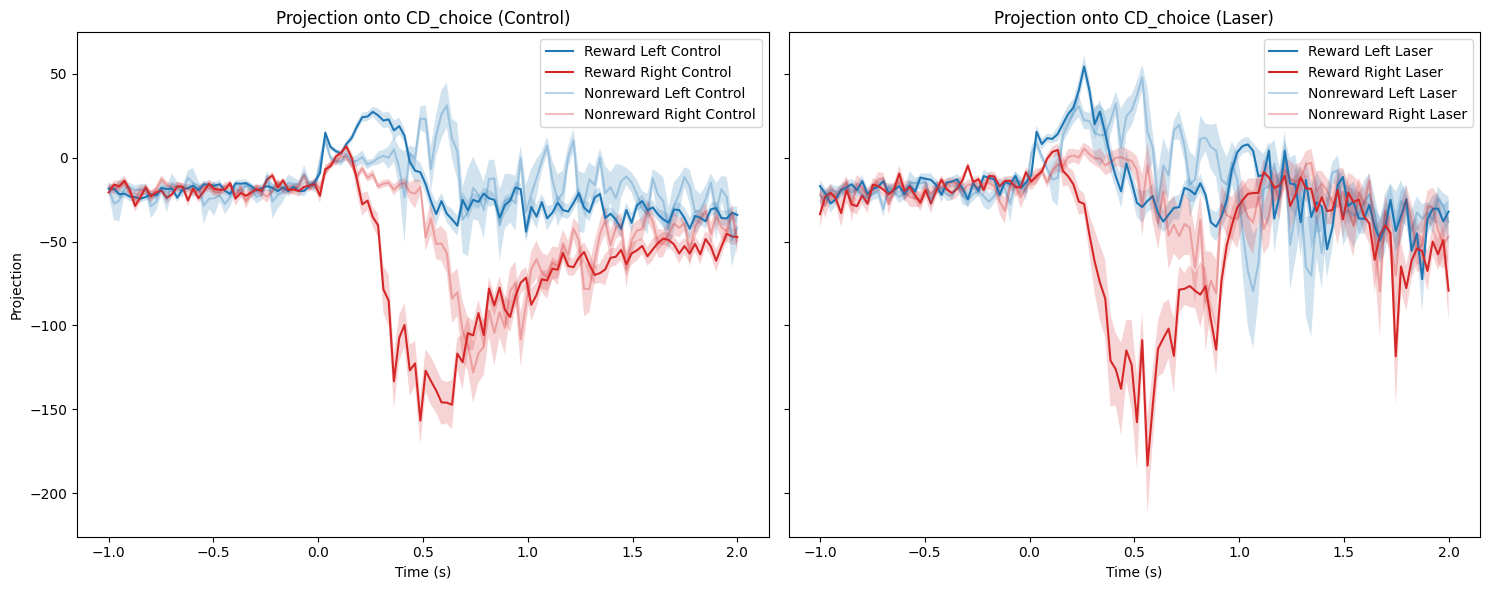

In [16]:
cd_choice = ndap.get_mod_index(left_rates, right_rates, type='cd')
aligned = aligned_trial_start

# Get projections for control
proj_reward_left_control = ndap.project(aligned['reward_left_control']['rate'], cd=cd_choice)
proj_reward_right_control = ndap.project(aligned['reward_right_control']['rate'], cd=cd_choice)
proj_nonreward_left_control = ndap.project(aligned['nonreward_left_control']['rate'], cd=cd_choice)
proj_nonreward_right_control = ndap.project(aligned['nonreward_right_control']['rate'], cd=cd_choice)

# Get projections for laser
proj_reward_left_laser = ndap.project(aligned['reward_left_laser']['rate'], cd=cd_choice)
proj_reward_right_laser = ndap.project(aligned['reward_right_laser']['rate'], cd=cd_choice)
proj_nonreward_left_laser = ndap.project(aligned['nonreward_left_laser']['rate'], cd=cd_choice)
proj_nonreward_right_laser = ndap.project(aligned['nonreward_right_laser']['rate'], cd=cd_choice)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# Left: Control
ndap.plot_sem(proj_reward_left_control, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Control', ax=axs[0])
ndap.plot_sem(proj_reward_right_control, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_left_control, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_right_control, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Control', ax=axs[0])
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Projection')
axs[0].set_title('Projection onto CD_choice (Control)')
axs[0].legend()

# Right: Laser
ndap.plot_sem(proj_reward_left_laser, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Laser', ax=axs[1])
ndap.plot_sem(proj_reward_right_laser, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_left_laser, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_right_laser, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Laser', ax=axs[1])
axs[1].set_xlabel('Time (s)')
axs[1].set_title('Projection onto CD_choice (Laser)')
axs[1].legend()

plt.tight_layout()
plt.show()


### 4.2. Plot PCA trajectory

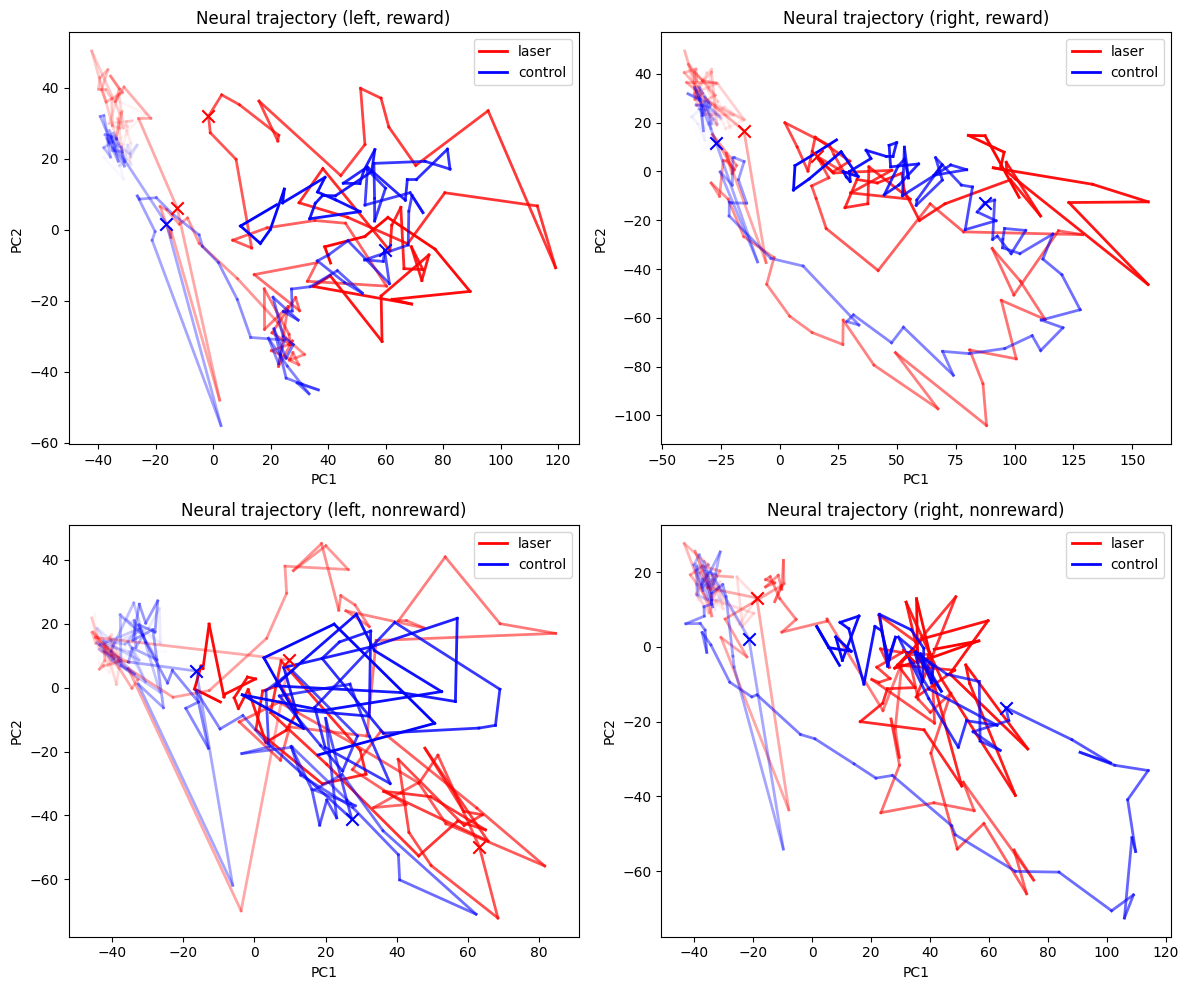

In [17]:
from sklearn.decomposition import PCA

# ─── Generate PCA ───────────────────────────────────────
control_data = ndap.combine_rates([left_rates_control, right_rates_control], axis=1)
control_data = np.nanmean(control_data, axis=1).T
pca_control = PCA(n_components=3).fit(control_data)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
key_time = [0, 1]

# ─── Top‐Left: Left Trials Trajectory ───────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red', ax=axs[0,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,0].legend()
axs[0,0].set_xlabel('PC1')
axs[0,0].set_ylabel('PC2')
axs[0,0].set_title('Neural trajectory (left, reward)')

# ─── Top‐Right: Right Trials Trajectory ────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[0,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,1].legend()
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[0,1].set_title('Neural trajectory (right, reward)')

# ─── Bottom‐Left: left no reward trajectory ─────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,0].legend()
axs[1,0].set_xlabel('PC1')
axs[1,0].set_ylabel('PC2')
axs[1,0].set_title('Neural trajectory (left, nonreward)')

# ─── Bottom‐Right: right no reward trajectory ───────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,1].legend()
axs[1,1].set_xlabel('PC1')
axs[1,1].set_ylabel('PC2')
axs[1,1].set_title('Neural trajectory (right, nonreward)')

plt.tight_layout()
plt.show()


## 5. Find the coding direction

### 1. Left and right axis

In [18]:
# Run to get decoder
window_size = 100   # in ms
decoders, accs = ndap.get_decoders(left_rates_control, right_rates_control, 
                                window_size_ms=window_size, bin_size_ms=bin_size, max_iter=10000)

Selected decoder accuracy: 0.9565217391304348


Text(0, 0.5, 'Projection (--> right)')

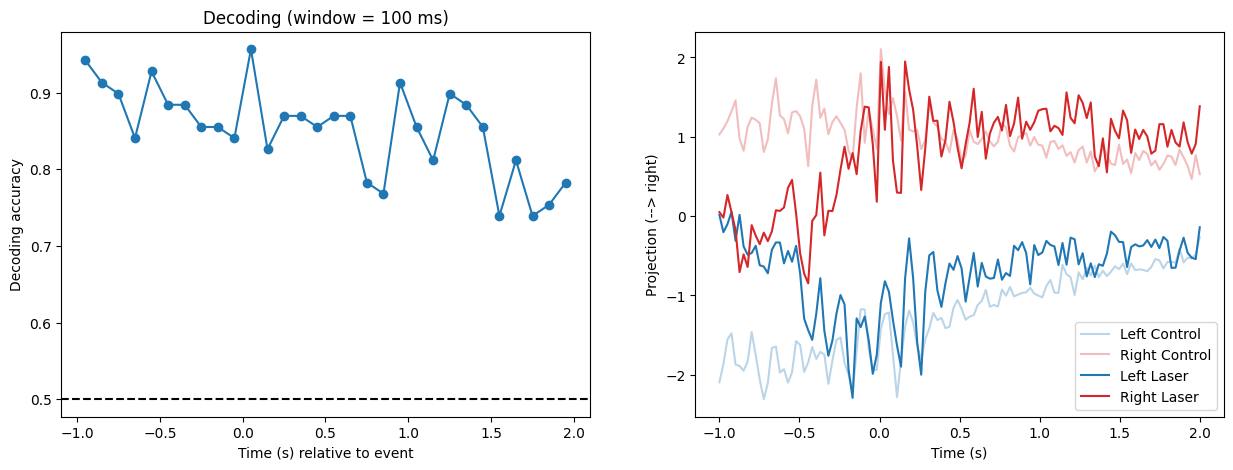

In [19]:
# Select decoder
# Note: -7 to -6, shape looks very different
index = np.argmax(accs)
print('Selected decoder accuracy: ' + str(accs[index]))
decoder_left_right = decoders[index]


fig, axs = plt.subplots(1,2, figsize=(15,5))
# plot accuracy vs. time (bin centers)
# compute time‐bin centers
n_bins = aligned['reward_left_laser']['params']['n_timestep']
window_size_in_bins = max(1, int(round(window_size / bin_size)))
n_windows    = int(np.ceil(n_bins / window_size_in_bins))
time_bins    = np.linspace(time_range[0], time_range[1], n_bins, endpoint=False) + bin_size/1000/2
time_centers = [
    time_bins[i*window_size_in_bins : min((i+1)*window_size_in_bins, n_bins)].mean()
    for i in range(n_windows)
]
# plot
axs[0].plot(time_centers, accs, '-o')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].set_xlabel('Time (s) relative to event')
axs[0].set_ylabel('Decoding accuracy')
axs[0].set_title(f'Decoding (window = {window_size} ms)')

# Plot projection
xaxis = np.linspace(time_range[0], time_range[1], n_bins)

left_control_trial_avg = np.nanmean(left_rates_control,axis=1)
right_control_trial_avg = np.nanmean(right_rates_control,axis=1)
proj_left_control = ndap.project(left_control_trial_avg, decoder_left_right)
proj_right_control = ndap.project(right_control_trial_avg, decoder_left_right)

left_laser_trial_avg = np.nanmean(left_rates_laser,axis=1)
right_laser_trial_avg = np.nanmean(right_rates_laser,axis=1)
proj_left_laser = ndap.project(left_laser_trial_avg, decoder_left_right)
proj_right_laser = ndap.project(right_laser_trial_avg, decoder_left_right)

axs[1].plot(xaxis, proj_left_control,  color=left_color,  alpha=alpha_ctrl,  label='Left Control')
axs[1].plot(xaxis, proj_right_control, color=right_color, alpha=alpha_ctrl,  label='Right Control')
axs[1].plot(xaxis, proj_left_laser,    color=left_color,  alpha=alpha_laser, label='Left Laser')
axs[1].plot(xaxis, proj_right_laser,   color=right_color, alpha=alpha_laser, label='Right Laser')

axs[1].legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Projection (--> right)')

Text(0.5, 1.0, 'Spearman ρ = -0.029, p = 0.729')

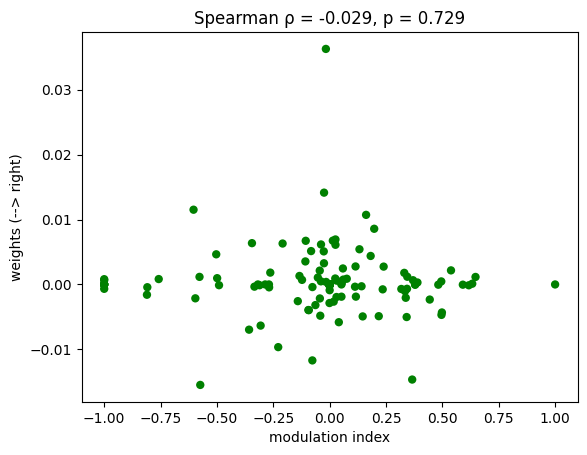

In [20]:
# Correlation of the decoder weights and laser_mod_index
w_units = decoder_left_right.coef_[0]
if criteria is not None: 
    mod_index_included = laser_mod_index[criteria]
else: 
    mod_index_included = laser_mod_index

from scipy.stats import spearmanr
r_spear, p_spear = spearmanr(mod_index_included, w_units)

plt.scatter(mod_index_included, w_units, color='green', edgecolor='None')
plt.xlabel('modulation index')
plt.ylabel('weights (--> right)')
plt.title(f"Spearman ρ = {r_spear:.3f}, p = {p_spear:.3g}")